In [1]:
import pandas as pd
import numpy as np
from anndata import AnnData
from scipy import sparse
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats
import scanpy as sc
import matplotlib.pyplot as plt
from adjustText import adjust_text  # pip install adjustText

def volcano_pretty(
    res,
    lfc_col="log2FoldChange",
    p_col="pvalue",
    padj_col="padj",
    lfc_thr=1.0,
    padj_thr=0.05,
    top_labels=15,
    title="Volcano: BRICHOS vs WT",
    figsize=(7, 6),
):
    """Beautiful volcano plot with smart labeling."""
    df = res.copy()
    df["neglog10p"] = -np.log10(df[p_col] + 1e-300)

    # significance flags
    sig = (df[padj_col] < padj_thr) & (df[lfc_col].abs() >= lfc_thr)
    up = sig & (df[lfc_col] > 0)
    dn = sig & (df[lfc_col] < 0)
    ns = ~sig

    # size scaling by significance
    df["size"] = np.clip(df["neglog10p"] / df["neglog10p"].max() * 60, 8, 60)

    # --- Plot ---
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=figsize)

    # non-significant
    ax.scatter(
        df.loc[ns, lfc_col],
        df.loc[ns, "neglog10p"],
        s=df.loc[ns, "size"],
        c="lightgrey",
        alpha=0.5,
        lw=0,
    )

    # down
    ax.scatter(
        df.loc[dn, lfc_col],
        df.loc[dn, "neglog10p"],
        s=df.loc[dn, "size"],
        c="#4575b4",
        alpha=0.8,
        lw=0,
        label=f"down (n={dn.sum()})",
    )

    # up
    ax.scatter(
        df.loc[up, lfc_col],
        df.loc[up, "neglog10p"],
        s=df.loc[up, "size"],
        c="#d73027",
        alpha=0.8,
        lw=0,
        label=f"up (n={up.sum()})",
    )

    # threshold lines
    ax.axvline(lfc_thr, color="k", lw=0.8, ls="--")
    ax.axvline(-lfc_thr, color="k", lw=0.8, ls="--")
    ax.axhline(-np.log10(padj_thr), color="k", lw=0.8, ls="--")

    # highlight top genes
    top = df.sort_values(p_col).head(top_labels)
    texts = []
    for _, r in top.iterrows():
        gene_name = r.name if not hasattr(r, "gene") else r.get("gene", r.name)
        texts.append(
            ax.text(
                r[lfc_col],
                r["neglog10p"],
                gene_name,
                fontsize=8,
                color="black",
                ha="left",
                va="bottom",
            )
        )
    adjust_text(texts, arrowprops=dict(arrowstyle="-", lw=0.3, color="gray"))

    # styling
    ax.set_xlabel("log2 fold change (BRICHOS vs WT)", fontsize=11)
    ax.set_ylabel("−log10(p-value)", fontsize=11)
    ax.set_title(title, fontsize=13, pad=15)
    ax.legend(frameon=False, fontsize=9, loc="upper left")
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()
# ---------------------------------------------------
# 0) your ST AnnData
# adata.obs must have: sample_id (mouse/section), condition (WT/PBS/BRICHOS)
# ---------------------------------------------------
adata = sc.read_h5ad('../data/ST_BRICHOS_region_subcluster.h5ad')
adata.X = adata.layers['counts']
adata.X = adata.X.astype(int)

/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:

# ---- 1. make pseudobulk per sample_id ----
X = adata.X
if sparse.issparse(X):
    X = X.tocsr()

sample_ids = adata.obs["sample_id"].astype(str).values
conditions  = adata.obs["treatment"].astype(str)

uniq_samples = pd.Index(np.unique(sample_ids), name="sample_id")
n_genes = adata.n_vars
n_samp  = len(uniq_samples)

pb_mat = np.zeros((n_genes, n_samp), dtype=np.int64)

for j, sid in enumerate(uniq_samples):
    mask = (sample_ids == sid)
    Xi = X[mask]
    pb_mat[:, j] = Xi.sum(axis=0).A.ravel() if sparse.issparse(Xi) else Xi.sum(axis=0)

counts_df = pd.DataFrame(pb_mat, index=adata.var_names, columns=uniq_samples)

# metadata: one row per sample
meta_df = (
    adata.obs[["sample_id", "treatment"]]
         .drop_duplicates()
         .set_index("sample_id")
         .loc[uniq_samples]  # align
)
meta_df["treatment"] = meta_df["treatment"].astype("category")

# ---- 2. turn into AnnData for pydeseq2 ----
ad = AnnData(X=counts_df.T.values)
ad.var_names = counts_df.index
ad.obs_names = counts_df.columns
ad.obs = meta_df.copy()

# make sure WT is the ref
if "WT" not in ad.obs["treatment"].cat.categories:
    raise ValueError("Need WT in ad.obs['condition'].")

inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    adata=ad,
    design_factors=["treatment"],
    refit_cooks=True,
    inference=inference,
)
dds.deseq2()

# ---- 3. contrasts ----
# PBS vs WT
pbs_stats = DeseqStats(dds, contrast=["treatment", "PBS", "WT"], inference=inference)
pbs_stats.summary()
res_pbs = pbs_stats.results_df

# BRICHOS vs WT
bri_stats = DeseqStats(dds, contrast=["treatment", "BRICHOS", "WT"], inference=inference)
bri_stats.summary()
res_bri = bri_stats.results_df

# BRICHOS vs PBS  ← THIS is the real “treatment effect on AD background”
bri_vs_pbs_stats = DeseqStats(dds, contrast=["treatment", "BRICHOS", "PBS"], inference=inference)
bri_vs_pbs_stats.summary()
res_bri_vs_pbs = bri_vs_pbs_stats.results_df

Using None as control genes, passed at DeseqDataSet initialization


/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/anndata/_core/anndata.py:774: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    ['P24215_101', 'P24215_201', 'P24215_301', 'P28052_102', 'P28052_103']

    Inferred to be: categorical

  value_idx = self._prep_dim_index(value.index, attr)
/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_79366/1091977581.py:42: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.00 seconds.

/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/sklearn/linear_model/_base.py:282: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_.T + self.intercept_
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/sklearn/linear_model/_base.py:282: RuntimeWarning: overflow encounter

Log2 fold change & Wald test p-value: treatment PBS vs WT
                  baseMean  log2FoldChange     lfcSE      stat    pvalue  \
Xkr4            831.184602       -0.094557  0.176633 -0.535329  0.592422   
Rp1              17.315928       -0.428619  0.605510 -0.707864  0.479030   
Sox17           454.766845        0.164629  0.171847  0.957994  0.338066   
Lypla1         1475.577090       -0.189398  0.129843 -1.458678  0.144654   
Tcea1          3700.238297       -0.134989  0.086642 -1.558011  0.119231   
...                    ...             ...       ...       ...       ...   
Arhgap6         762.590070        0.318342  0.260751  1.220864  0.222138   
Hccs           2001.304922        0.005631  0.109996  0.051192  0.959173   
Mid1            303.077800        0.716308  0.775071  0.924184  0.355391   
4933400A11Rik     1.056235       -0.265714  2.395023 -0.110944  0.911661   
Asmt              9.013920       -0.571835  0.700418 -0.816419  0.414260   

                   padj  
Xkr

... done in 0.32 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: treatment BRICHOS vs WT
                  baseMean  log2FoldChange     lfcSE      stat    pvalue  \
Xkr4            831.184602       -0.155693  0.189805 -0.820282  0.412056   
Rp1              17.315928       -0.068416  0.653790 -0.104645  0.916657   
Sox17           454.766845        0.035966  0.185419  0.193970  0.846199   
Lypla1         1475.577090       -0.243918  0.139596 -1.747309  0.080584   
Tcea1          3700.238297       -0.159159  0.093053 -1.710413  0.087190   
...                    ...             ...       ...       ...       ...   
Arhgap6         762.590070        0.203831  0.279315  0.729751  0.465542   
Hccs           2001.304922        0.034072  0.118084  0.288539  0.772934   
Mid1            303.077800        0.644060  0.828772  0.777126  0.437085   
4933400A11Rik     1.056235        0.417014  2.551700  0.163426  0.870183   
Asmt              9.013920       -0.454044  0.770779 -0.589071  0.555814   

                   padj  

... done in 0.33 seconds.



In [3]:
top_atten

NameError: name 'top_atten' is not defined

In [ ]:
top_atten.index

/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_24179/303562406.py:23: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


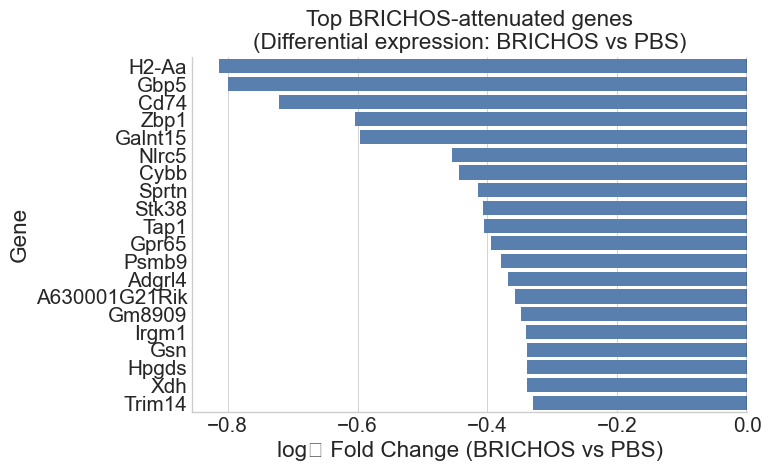

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Select and sort ---
subset = res_bri_vs_pbs.loc[top_atten.index].copy()
subset = subset.sort_values("log2FoldChange")

# --- Plot ---
plt.figure(figsize=(8, 5))
sns.barplot(
    data=subset,
    y=subset.index,
    x="log2FoldChange",
    color="#4a7ebb",
    edgecolor="none"
)

plt.axvline(0, color="k", lw=1)
plt.xlabel("log₂ Fold Change (BRICHOS vs PBS)")
plt.ylabel("Gene")
plt.title("Top BRICHOS-attenuated genes\n(Differential expression: BRICHOS vs PBS)")

plt.tight_layout()
plt.show()

In [105]:
res_bri_vs_pbs_filt = res_bri_vs_pbs[res_bri_vs_pbs.baseMean > 150]

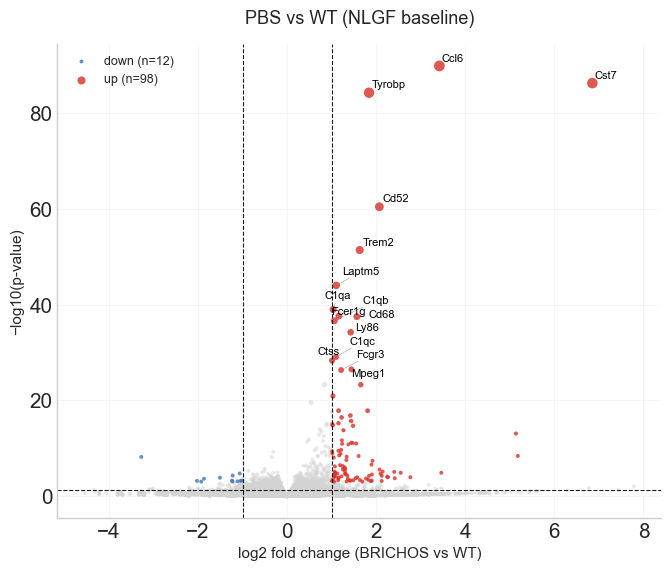

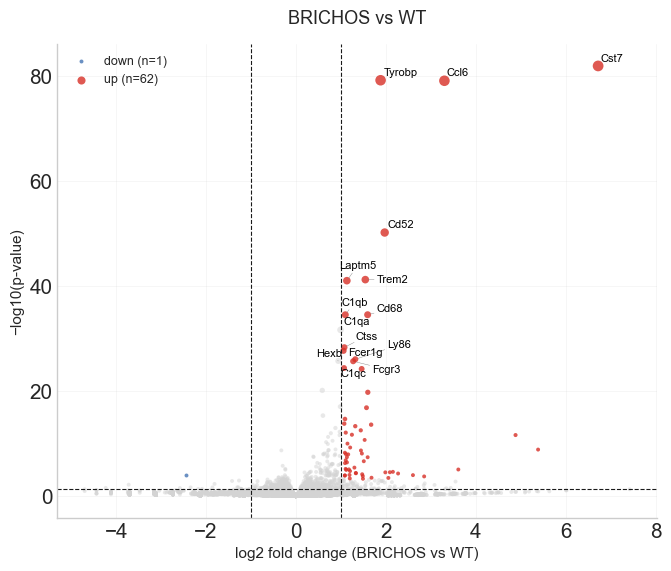

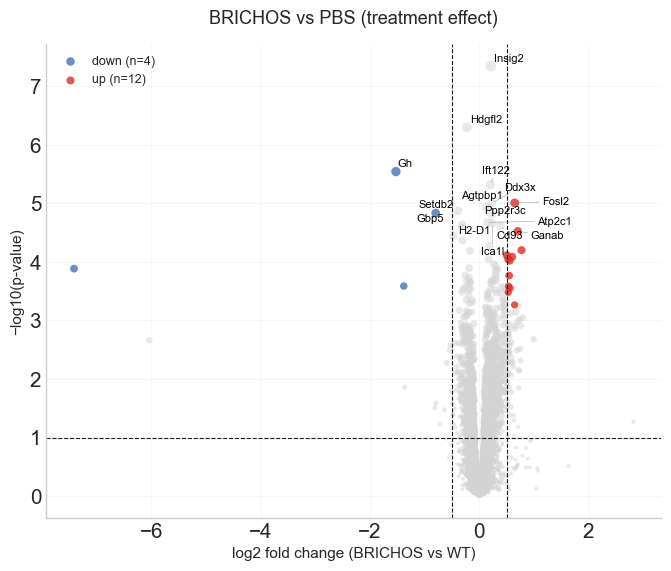

In [110]:
volcano_pretty(res_pbs,  title="PBS vs WT (NLGF baseline)")
volcano_pretty(res_bri,  title="BRICHOS vs WT")
volcano_pretty(res_bri_vs_pbs_filt, title="BRICHOS vs PBS (treatment effect)",  lfc_thr=0.5,
    padj_thr=0.1,
    top_labels=15)

/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_24179/3018051136.py:69: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_24179/3018051136.py:69: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_24179/3018051136.py:69: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/christoffer/miniconda3/env

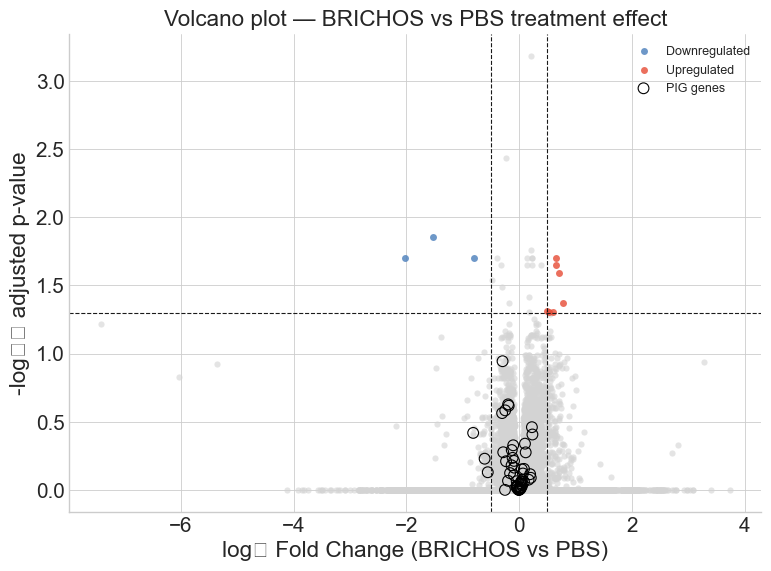

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Copy and clean up ---
res = res_bri_vs_pbs.copy()
res["log2FoldChange"] = res["log2FoldChange"].replace([np.inf, -np.inf], np.nan).fillna(0)
res["padj"] = res["padj"].fillna(1.0)

# --- Significance thresholds ---
lfc_thr = 0.5
padj_thr = 0.05

# --- Calculate significance ---
res["neglog10padj"] = -np.log10(res["padj"] + 1e-300)
res["is_up"] = (res["log2FoldChange"] > lfc_thr) & (res["padj"] < padj_thr)
res["is_down"] = (res["log2FoldChange"] < -lfc_thr) & (res["padj"] < padj_thr)

# --- If PIG list exists ---
if "pig_genes" in locals():
    res["is_PIG"] = res.index.isin(pig_genes)
else:
    res["is_PIG"] = False

# --- Plot ---
plt.figure(figsize=(8, 6))
plt.style.use("seaborn-v0_8-whitegrid")

# Base (non-significant)
sns.scatterplot(
    data=res.loc[~(res["is_up"] | res["is_down"])],
    x="log2FoldChange", y="neglog10padj",
    color="lightgrey", s=20, alpha=0.6, linewidth=0
)

# Downregulated
sns.scatterplot(
    data=res.loc[res["is_down"]],
    x="log2FoldChange", y="neglog10padj",
    color="#4a7ebb", s=25, alpha=0.8, linewidth=0, label="Downregulated"
)

# Upregulated
sns.scatterplot(
    data=res.loc[res["is_up"]],
    x="log2FoldChange", y="neglog10padj",
    color="#e64b35", s=25, alpha=0.8, linewidth=0, label="Upregulated"
)

# PIG overlay (outline only)
sns.scatterplot(
    data=res.loc[res["is_PIG"]],
    x="log2FoldChange", y="neglog10padj",
    facecolors="none", edgecolors="black", s=60, linewidth=0.8, label="PIG genes"
)

# Threshold lines
plt.axvline(lfc_thr, color="k", ls="--", lw=0.8)
plt.axvline(-lfc_thr, color="k", ls="--", lw=0.8)
plt.axhline(-np.log10(padj_thr), color="k", ls="--", lw=0.8)

# Labels
plt.xlabel("log₂ Fold Change (BRICHOS vs PBS)")
plt.ylabel("-log₁₀ adjusted p-value")
plt.title("Volcano plot — BRICHOS vs PBS treatment effect")
plt.legend(frameon=False, fontsize=9, loc="upper right")

plt.tight_layout()
plt.show()

In [23]:
import pandas as pd
import numpy as np

# Merge DESeq2 results on shared genes
common = res_pbs.index.intersection(res_bri.index)
df = pd.DataFrame({
    "log2FC_pbs": res_pbs.loc[common, "log2FoldChange"],
    "padj_pbs":   res_pbs.loc[common, "padj"],
    "log2FC_bri": res_bri.loc[common, "log2FoldChange"],
    "padj_bri":   res_bri.loc[common, "padj"],
})

# Compute treatment modulation
df["delta_LFC"] = df["log2FC_bri"] - df["log2FC_pbs"]

# Keep only genes significantly changed in PBS vs WT
sig = df["padj_pbs"] < 0.05
df_sig = df.loc[sig].copy()

# Sort by most negative delta (strongest attenuation)
df_sorted = df_sig.sort_values("delta_LFC")

# Show top 20
top_atten = df_sorted.head(20)
top_increased = df_sorted.tail(20)

top_atten

,log2FC_pbs,padj_pbs,log2FC_bri,padj_bri,delta_LFC
H2-Aa,2.263986,9.186045e-03,1.449984,0.523009,-0.814002
Gbp5,0.956878,3.346207e-02,0.157837,0.982208,-0.799041
Cd74,2.551067,1.611711e-03,1.829475,0.195604,-0.721592
Zbp1,1.488307,2.631097e-02,0.884535,0.753900,-0.603771
Galnt15,1.352741,5.022162e-03,0.756774,0.653755,-0.595967
Nlrc5,1.542189,1.279076e-02,1.088222,0.429733,-0.453967
Cybb,1.917050,8.526229e-06,1.474104,0.008937,-0.442946
Sprtn,0.911143,2.896484e-02,0.496291,0.835928,-0.414852
Stk38,1.894349,4.921217e-05,1.487803,0.016677,-0.406546
Tap1,0.810646,3.109471e-02,0.405989,0.890311,-0.404657


In [34]:
top_increased

,log2FC_pbs,padj_pbs,log2FC_bri,padj_bri,delta_LFC
Khdrbs1,-0.481112,0.011073,-0.169530,0.951347,0.311582
Sphkap,-0.758949,0.022380,-0.437799,0.761603,0.321150
Cited2,-0.432260,0.041627,-0.097364,0.977622,0.334895
Ehd1,-0.769811,0.002712,-0.408576,0.677256,0.361236
Arrb2,-0.640901,0.023512,-0.275463,0.922009,0.365437
Atp5g1,-0.574731,0.045931,-0.205636,0.971343,0.369095
Sh3bp4,-0.761969,0.025242,-0.350521,0.902481,0.411448
Ptgs2,-0.782802,0.012344,-0.359075,0.887401,0.423727
Dgat1,-0.739320,0.003308,-0.310044,0.885324,0.429277
Zic5,-0.947668,0.032792,-0.496636,0.870759,0.451032


In [38]:
pig_genes = ['Abi3',
  'Apoe',
  'Axl',
  'B2m',
  'C1qa',
  'C1qb',
  'C1qc',
  'C3ar1',
  'C4b',
  'Ccl6',
  'Cd33',
  'Cd68',
  'Cd9',
  'Csf1',
  'Csf1r',
  'Cst7',
  'Ctss',
  'Ctsb',
  'Ctsd',
  'Cyba',
  'Cyp27a1',
  'Dock2',
  'Fcgr1',
  'Fcgr2b',
  'Fcgr3',
  'Fcer1g',
  'Fcrls',
  'Gpnmb',
  'Grn',
  'Gusb',
  'Hexb',
  'H2-Ab1',
  'H2-Eb1',
  'H2-Aa',
  'Itgax',
  'Laptm5',
  'Lgmn',
  'Lyz2',
  'Mpeg1',
  'Msr1',
  'Pf4',
  'Plek',
  'Prdx6',
  'Psap',
  'S100a4',
  'S100a6',
  'S100a11',
  'Spp1',
  'Timp2',
  'Trem2',
  'Tyrobp',
  'Vim',
  'Vsir']

/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_24179/3843700612.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"$\\it{{{g}}}$" for g in top_atten.index], fontsize=10)


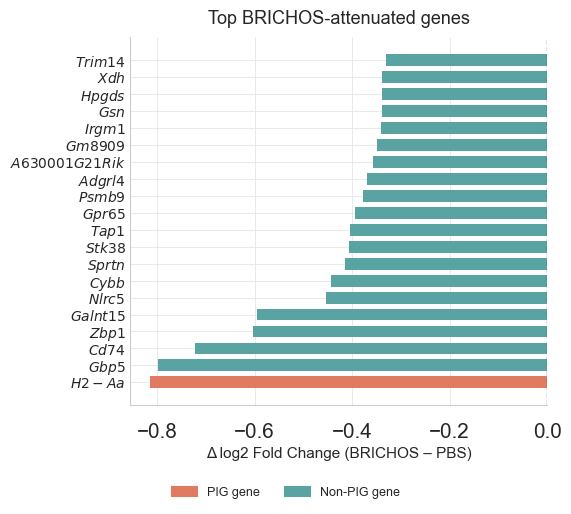

In [53]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# --- Modern theme ---
sns.set_theme(style="whitegrid", context="talk", font_scale=0.9)
plt.rcParams.update({
    "font.family": "Arial",
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.color": "#e5e5e5",
    "grid.linestyle": "-",
    "grid.linewidth": 0.6,
})

# Assign colors (red = PIG, blue = non-PIG)
pig_col = "#e07b62"     # soft coral
nonpig_col = "#5aa3a3"  # teal grey
colors = top_atten.index.map(lambda g: pig_col if g in pig_genes else nonpig_col)
# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5))
ax.barh(
    top_atten.index, top_atten["delta_LFC"],
    color=colors, edgecolor="none", height=0.7
)
ax.axvline(0, color="k", lw=1, ls="--", alpha=0.6)

# Axis labels and title
ax.set_xlabel("Δ log2 Fold Change (BRICHOS – PBS)", fontsize=11)
ax.set_ylabel("")
ax.set_title("Top BRICHOS-attenuated genes", fontsize=13, pad=10)

# Italicized + smaller y-axis tick labels
ax.set_yticklabels([f"$\\it{{{g}}}$" for g in top_atten.index], fontsize=10)
ax.tick_params(axis="y", length=0)

# Legend below the plot
pig_patch = mpatches.Patch(color=pig_col, label="PIG gene")
nonpig_patch = mpatches.Patch(color=nonpig_col, label="Non-PIG gene")

fig.legend(
    handles=[pig_patch, nonpig_patch],
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=9,
    bbox_to_anchor=(0.5, -0.05),  # slightly below the figure
)

sns.despine(left=False, bottom=False)
plt.tight_layout()
plt.show()

In [58]:
top_atten_genes = ['Trim14',
 'Xdh',
 'Hpgds',
 'Gsn',
 'Irgm1',
 'Gm8909',
 'A630001G21Rik',
 'Adgrl4',
 'Psmb9',
 'Gpr65',
 'Tap1',
 'Stk38',
 'Sprtn',
 'Cybb',
 'Nlrc5',
 'Galnt15',
 'Zbp1',
 'Cd74',
 'Gbp5',
 'H2-Aa']

In [59]:
res_bri_vs_pbs.loc[top_atten_genes]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Trim14,195.700791,-0.330453,0.115224,-2.867927,0.004132,0.185193
Xdh,514.540872,-0.338618,0.143279,-2.363337,0.018111,0.303898
Hpgds,55.138621,-0.338627,0.292907,-1.156092,0.247644,0.767087
Gsn,1197.526389,-0.339189,0.150632,-2.251779,0.024336,0.346170
Irgm1,550.577935,-0.340553,0.137358,-2.479317,0.013163,0.281984
Gm8909,237.703710,-0.348660,0.148099,-2.354230,0.018561,0.308381
A630001G21Rik,110.816448,-0.357763,0.143914,-2.485948,0.012921,0.281671
Adgrl4,952.716748,-0.368873,0.108468,-3.400743,0.000672,0.107253
Psmb9,209.348751,-0.378412,0.141792,-2.668778,0.007613,0.237598
Gpr65,59.524756,-0.393652,0.219203,-1.795834,0.072521,0.520934


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_24179/1314202272.py:30: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


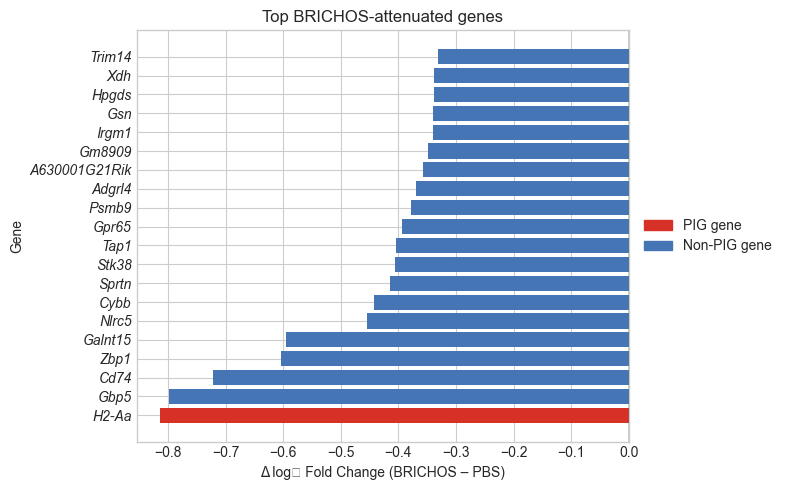

In [42]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Assign colors (red = PIG, blue = non-PIG)
colors = top_atten.index.map(lambda g: "#d73027" if g in pig_genes else "#4575b4")

# Create figure
plt.figure(figsize=(8, 5))
bars = plt.barh(top_atten.index, top_atten["delta_LFC"], color=colors)
plt.axvline(0, color="k", lw=1)

plt.xlabel("Δ log₂ Fold Change (BRICHOS – PBS)")
plt.ylabel("Gene")
plt.title("Top BRICHOS-attenuated genes")

# Italicize y-axis tick labels (gene names)
plt.yticks(fontstyle="italic")

# Legend (outside the plot)
pig_patch = mpatches.Patch(color="#d73027", label="PIG gene")
nonpig_patch = mpatches.Patch(color="#4575b4", label="Non-PIG gene")
plt.legend(
    handles=[pig_patch, nonpig_patch],
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),   # move outside the right edge
    borderaxespad=0,
)

plt.tight_layout()
plt.show()

In [115]:
sc.pp.normalize_total(adata, target_sum=1000)
sc.pp.log1p(adata)

In [ ]:
ax = sc.pl.stacked_violin(ad, marker_genes, groupby='cell_type',
                         #var_group_positions=[(7, 8)], 
                          #var_group_labels=['NK']
                         )

In [131]:
adata.X

array([[0.07154591, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.0783179 , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.05620404, 0.        ,
        0.        ]], shape=(25660, 18751), dtype=float32)

In [ ]:
import scanpy as sc

# --- Define your PIG gene list ---
pig_genes = ['Abi3',
  'Apoe',
  'Axl',
  'B2m',
  'C1qa',
  'C1qb',
  'C1qc',
  'C3ar1',
  'C4b',
  'Ccl6',
  'Cd33',
  'Cd68',
  'Cd9',
  'Csf1',
  'Csf1r',
  'Cst7',
  'Ctss',
  'Ctsb',
  'Ctsd',
  'Cyba',
  'Cyp27a1',
  'Dock2',
  'Fcgr1',
  'Fcgr2b',
  'Fcgr3',
  'Fcer1g',
  'Fcrls',
  'Gpnmb',
  'Grn',
  'Gusb',
  'Hexb',
  'H2-Ab1',
  'H2-Eb1',
  'H2-Aa',
  'Itgax',
  'Laptm5',
  'Lgmn',
  'Lyz2',
  'Mpeg1',
  'Msr1',
  'Pf4',
  'Plek',
  'Prdx6',
  'Psap',
  'S100a4',
  'S100a6',
  'S100a11',
  'Spp1',
  'Timp2',
  'Trem2',
  'Tyrobp',
  'Vim',
  'Vsir']

# --- Quick check for missing genes ---
found_genes = [g for g in pig_genes if g in adata.var_names]
print(f"Found {len(found_genes)} PIG genes in data: {found_genes}")

# --- Global violin plot across treatments ---
sc.pl.he(adata,
    var_names=found_genes,
    groupby = 'treatment'
)

Found 53 PIG genes in data: ['Abi3', 'Apoe', 'Axl', 'B2m', 'C1qa', 'C1qb', 'C1qc', 'C3ar1', 'C4b', 'Ccl6', 'Cd33', 'Cd68', 'Cd9', 'Csf1', 'Csf1r', 'Cst7', 'Ctss', 'Ctsb', 'Ctsd', 'Cyba', 'Cyp27a1', 'Dock2', 'Fcgr1', 'Fcgr2b', 'Fcgr3', 'Fcer1g', 'Fcrls', 'Gpnmb', 'Grn', 'Gusb', 'Hexb', 'H2-Ab1', 'H2-Eb1', 'H2-Aa', 'Itgax', 'Laptm5', 'Lgmn', 'Lyz2', 'Mpeg1', 'Msr1', 'Pf4', 'Plek', 'Prdx6', 'Psap', 'S100a4', 'S100a6', 'S100a11', 'Spp1', 'Timp2', 'Trem2', 'Tyrobp', 'Vim', 'Vsir']


/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_24179/3101433990.py:55: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


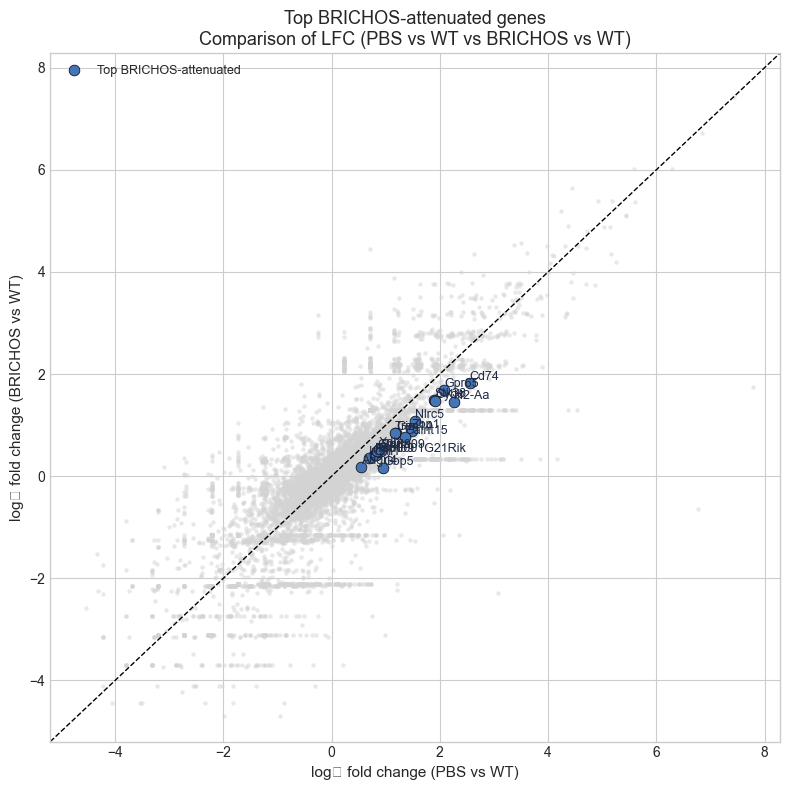

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming you already have `res_pbs` and `res_bri` dataframes
# and have computed `df` as before:
common = res_pbs.index.intersection(res_bri.index)
df = pd.DataFrame({
    "log2FC_pbs": res_pbs.loc[common, "log2FoldChange"],
    "log2FC_bri": res_bri.loc[common, "log2FoldChange"],
}).dropna()
df["delta"] = df["log2FC_bri"] - df["log2FC_pbs"]

# --- your top attenuated gene list (from the barplot) ---
top_atten_genes = [
    "Trim14","Xdh","Hp gds","Gsn","Irgm1","Gm8909","A630001G21Rik",
    "Adgrl4","Psmb9","Gpr65","Tap1","Stk38","Sprtn","Cybb","Nlrc5",
    "Galnt15","Zbp1","Cd74","Gbp5","H2-Aa"
]

# --- Plot ---
plt.figure(figsize=(8,8))
plt.style.use("seaborn-v0_8-whitegrid")

# Background (all genes)
plt.scatter(df["log2FC_pbs"], df["log2FC_bri"],
            s=10, c="lightgrey", alpha=0.5, lw=0)

# Highlight top attenuated genes
top_df = df.loc[df.index.intersection(top_atten_genes)]
plt.scatter(top_df["log2FC_pbs"], top_df["log2FC_bri"],
            s=60, c="#4575b4", lw=0.5, edgecolors="black",
            label="Top BRICHOS-attenuated")

# Diagonal line (equal regulation)
lims = [
    min(df["log2FC_pbs"].min(), df["log2FC_bri"].min()) - 0.5,
    max(df["log2FC_pbs"].max(), df["log2FC_bri"].max()) + 0.5,
]
plt.plot(lims, lims, "k--", lw=1)

# Labels for top attenuated
for gene, row in top_df.iterrows():
    plt.text(
        row["log2FC_pbs"], row["log2FC_bri"],
        gene, fontsize=9, ha="left", va="bottom",
        color="#1f2a44"
    )

# Aesthetics
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("log₂ fold change (PBS vs WT)", fontsize=11)
plt.ylabel("log₂ fold change (BRICHOS vs WT)", fontsize=11)
plt.title("Top BRICHOS-attenuated genes\nComparison of LFC (PBS vs WT vs BRICHOS vs WT)", fontsize=13)
plt.legend(frameon=False, fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()